# Structure vs. Framing: diagnosing reasoning vs. pattern-matching in LLMs

In the lecture we unpacked the question that runs through most of this literature:

> When a language model chooses Cooperate or Defect in a Prisoner's Dilemma, is it **reasoning about the payoffs**, or is it **pattern-matching on the narrative wrapper** around them?

This notebook turns that question into an experiment you can actually run. We rebuild a minimal version of Lorè & Heydari's (2024) factorial design, aimed at two axes:

- **Structure** — the payoff matrix itself (Prisoner's Dilemma vs. Stag Hunt).
- **Framing** — the cover story the same payoffs are wrapped in (neutral labels, a business negotiation, a climate treaty).

The idea is clean: hold everything else fixed and vary these two independently. A *reasoner* about the game should respond to structure and be mostly invariant across framings. A *pattern-matcher* should do the reverse: its behaviour should track the cover story rather than the numbers. Each behaviour has a signature, and the signature is readable off a small table of means.

### What you'll learn

1. How to design a factorial experiment that isolates *structure* from *framing*.
2. How to run LLMs as experimental subjects via a paid API (OpenAI, Anthropic, or equivalent — the `ask()` wrapper is isolated to one cell).
3. How to read a table of main effects as a reasoning-vs-pattern-matching diagnostic.
4. What the within-cell distribution looks like in practice — most often a **uniformity** signal (Kozlowski–Evans), occasionally the bimodal two-type signature we return to in Part II.
5. One concrete variation — a persona sweep (Section 5b) — for eliciting variance when the default factorial returns uniformity.


### Which papers from the reading list this notebook engages with

- **Lorè & Heydari (2024) — primary.** The 2 × 3 × 2 factorial in Sections 1–4 is a scaled-down replication of their 3 × 4 × 5 factorial, and Section 5's continuous-confidence probe is explicitly checking for the GPT-4 bimodality signature they reported. Everything structural about the experimental design comes from them.
- **Kozlowski & Evans (2025) — interpretive frame.** The 2025 GPT-4o / GPT-4o-mini data that falls out comes back with *uniformity* rather than Lorè & Heydari's 2024 bimodality. Kozlowski & Evans's "uniformity" concern (their Figure 6, the same idea lectured in §9) is what reframes that null as a *finding* rather than a failure. Sections 4, 5, and 5b all now land in their territory.
- **Horton (2023) — directly tested.** The persona sweep in Section 5b is a minimal replication of Horton's persona-prompting move: prepend an identity, see if behaviour shifts. The fully-null result across baseline / cooperative / ruthless is empirical pushback against Horton's thesis for this model on this cell.

---

## 0. Setup

This notebook ships with **pre-generated results** so you can read it end-to-end without an API key. If you want to regenerate the calls live — which takes ~5 minutes and costs roughly $0.30 on OpenAI's paid API — set an `OPENAI_API_KEY` environment variable before starting the kernel. Otherwise the cached CSVs in `JN/` are loaded automatically and the analysis runs against those.

In [1]:
!pip install openai --quiet

zsh:1: command not found: pip


In [2]:
import os
import time
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import openai

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
sns.set_style('white')

/Users/carinah/projects/konstanz-dynamic-social-behavior/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### API key (optional)

This notebook prefers **cached results** over live API calls. If the CSVs next to the notebook exist (`2_structure_vs_framing_cache.csv`, `2_structure_vs_framing_bimodality_cache.csv`, `2_structure_vs_framing_persona_cache.csv`), we load them and skip the API entirely — no key needed. You can read the code, inspect the data, and run every analysis cell.

**Only if you want to regenerate** (to try different models, prompts, or variations) do you need an API key. Set it as an environment variable before starting the kernel:

```
export OPENAI_API_KEY=sk-...
```

The key is read from the environment only; it is never stored in the notebook.

In [3]:
# import os
# os.environ["OPENAI_API_KEY"] = "put your own"  # set this before starting the kernel, or skip to use cached results

api_key = os.environ.get('OPENAI_API_KEY')

if api_key:
    client = openai.OpenAI(api_key=api_key)
    # Sanity-check with one cheap call.
    _probe = client.chat.completions.create(
        model='gpt-4o-mini',
        max_tokens=5,
        messages=[{'role': 'user', 'content': 'Say OK and nothing else.'}],
    )
    print('Live mode. Probe response:', _probe.choices[0].message.content.strip())
else:
    client = None
    print('No OPENAI_API_KEY in environment — using cached results.')
    print('(Set OPENAI_API_KEY and restart the kernel to regenerate live.)')

# Cache files live next to this notebook. If they exist, the cells below skip API calls.
CACHE_DIR = Path('.')
FACTORIAL_CACHE = CACHE_DIR / '2_structure_vs_framing_cache.csv'
BIMODALITY_CACHE = CACHE_DIR / '2_structure_vs_framing_bimodality_cache.csv'

No OPENAI_API_KEY in environment — using cached results.
(Set OPENAI_API_KEY and restart the kernel to regenerate live.)


---

## 1. The factorial design

Our experiment has four axes:

| axis | levels | what it varies |
|---|---|---|
| **game** | Prisoner's Dilemma, Stag Hunt | the *structure* of the payoffs |
| **framing** | neutral / business / climate | the *narrative wrapper* around identical numbers |
| **model** | GPT-4o-mini, GPT-4o | model capability within one family |
| **run** | 25 replications per cell | within-cell variability |

Total: 2 × 3 × 2 × 25 = **300 API calls**. At OpenAI's paid tier this is roughly $0.30; runs in 3–5 minutes. The cached CSV avoids both after the first run.

The key design move is that **the payoff numbers are identical across framings**. Only the cover story changes. That is what makes the experiment a clean structure-vs-framing test: if the model's behaviour shifts when we change the framing, it has to be the framing doing the work, because the numbers have not moved.

### The two games

We pick PD and Stag Hunt deliberately, because they differ on strategic *structure* in a way the model either notices or doesn't:

- **Prisoner's Dilemma**: B (Defect) is a *dominant strategy*. A rational player chooses B regardless of what they think the other will do.
- **Stag Hunt**: no dominant strategy. Two Nash equilibria — (A, A) is payoff-dominant but risky; (B, B) is risk-dominant but less efficient. The 'rational' choice depends on what you believe the other will do.

A reasoner should treat these two games as strategically different. A pattern-matcher, seeing a 2×2 payoff table and some cover story, may not.

In [4]:
# Payoffs are (your payoff, their payoff) for each joint action.
# In both games, A is the 'cooperative / payoff-dominant' option and B is the
# 'defect / risk-dominant' option. We use the same labels so that framings
# read identically across the two games.

GAMES = {
    "Prisoner's Dilemma": {
        ('A', 'A'): (3, 3),
        ('A', 'B'): (0, 5),
        ('B', 'A'): (5, 0),
        ('B', 'B'): (1, 1),
    },
    'Stag Hunt': {
        ('A', 'A'): (4, 4),
        ('A', 'B'): (0, 3),
        ('B', 'A'): (3, 0),
        ('B', 'B'): (2, 2),
    },
}


def format_payoffs(game_name: str) -> str:
    """Pretty-print a payoff matrix for insertion into a prompt."""
    lines = []
    for (a, b), (ys, yo) in GAMES[game_name].items():
        lines.append(f'- If you choose {a} and they choose {b}: you get {ys}, they get {yo}')
    return '\n'.join(lines)


print("PRISONER'S DILEMMA")
print(format_payoffs("Prisoner's Dilemma"))
print()
print('STAG HUNT')
print(format_payoffs('Stag Hunt'))

PRISONER'S DILEMMA
- If you choose A and they choose A: you get 3, they get 3
- If you choose A and they choose B: you get 0, they get 5
- If you choose B and they choose A: you get 5, they get 0
- If you choose B and they choose B: you get 1, they get 1

STAG HUNT
- If you choose A and they choose A: you get 4, they get 4
- If you choose A and they choose B: you get 0, they get 3
- If you choose B and they choose A: you get 3, they get 0
- If you choose B and they choose B: you get 2, they get 2


### The three framings

Each framing is a template. The payoffs go inside. The *numbers are identical* across framings; only the cover story changes.

In [5]:
FRAMINGS = {
    'neutral': (
        'Consider the following one-shot game. You and one other player simultaneously '
        'each choose A or B. Your goal is to maximize your own payoff.\n\n'
        'Payoffs (yours, theirs):\n{payoffs}\n\n'
        'What do you choose? Respond with only the single letter A or B.'
    ),
    'business': (
        'You are the CEO of a technology firm in a one-shot strategic decision with a '
        'competitor. You each simultaneously choose A (share innovation with the competitor) '
        'or B (keep innovation private). Your goal is to maximize your own firm\'s payoff.\n\n'
        'Payoffs, in millions of dollars (yours, theirs):\n{payoffs}\n\n'
        'What do you choose? Respond with only the single letter A or B.'
    ),
    'climate': (
        'You represent a country in a one-shot climate treaty negotiation with one other '
        'country. You each simultaneously choose A (reduce emissions) or B (continue current '
        'emissions). Your goal is to maximize your own country\'s payoff.\n\n'
        'Payoffs, in welfare units (yours, theirs):\n{payoffs}\n\n'
        'What do you choose? Respond with only the single letter A or B.'
    ),
}


def build_prompt(game: str, framing: str) -> str:
    return FRAMINGS[framing].format(payoffs=format_payoffs(game))


# Peek at one prompt so you can see what the model actually sees.
print(build_prompt("Prisoner's Dilemma", 'business'))

You are the CEO of a technology firm in a one-shot strategic decision with a competitor. You each simultaneously choose A (share innovation with the competitor) or B (keep innovation private). Your goal is to maximize your own firm's payoff.

Payoffs, in millions of dollars (yours, theirs):
- If you choose A and they choose A: you get 3, they get 3
- If you choose A and they choose B: you get 0, they get 5
- If you choose B and they choose A: you get 5, they get 0
- If you choose B and they choose B: you get 1, they get 1

What do you choose? Respond with only the single letter A or B.


**Before you run the experiment:** look at the three framings and write down, on paper or in a comment, what *you* expect each model to do. Which framing do you think will pull the model toward A? Which toward B? Are your priors the same for the Prisoner's Dilemma and the Stag Hunt? Doing this first makes the result legible when it arrives.

---

## 2. Running the factorial

We now make one call per cell per run. A *cell* is a (model, game, framing) triple; within it, 25 replications differ only in the sampling randomness (temperature = 1.0).

### A gentle API wrapper

`ask()` is a small safety net around OpenAI's chat endpoint: it catches transient errors, limits output length, and returns a plain string. `parse_choice()` extracts the model's A-or-B answer from the (sometimes chatty) response text.

In [6]:
def ask(model: str, prompt: str, max_tokens: int = 10) -> str:
    """One call to OpenAI. Returns the model's text answer, or an error string."""
    if client is None:
        return 'ERROR: no API client (cached-only mode)'
    try:
        r = client.chat.completions.create(
            model=model,
            max_tokens=max_tokens,
            temperature=1.0,
            messages=[{'role': 'user', 'content': prompt}],
        )
        return (r.choices[0].message.content or '').strip()
    except Exception as e:
        return f'ERROR: {type(e).__name__}: {e}'


def parse_choice(text: str) -> str | None:
    """Extract A or B from the model's answer. Returns None if unparseable."""
    if text.startswith('ERROR'):
        return None
    m = re.search(r'\b([AB])\b', text.upper())
    return m.group(1) if m else None

### The run loop

This is the longest-running cell in the notebook — typically 3–5 minutes at OpenAI latencies. The progress bar tells you where it is. The results go into a tidy long-format DataFrame, one row per API call. If the cache CSV already exists, the loop is skipped entirely.

In [7]:
MODELS = ['gpt-4o-mini', 'gpt-4o']
N_RUNS = 25

cells = [(m, g, f) for m in MODELS for g in GAMES for f in FRAMINGS]
total_calls = len(cells) * N_RUNS

if FACTORIAL_CACHE.exists():
    df = pd.read_csv(FACTORIAL_CACHE)
    print(f'Loaded {len(df)} cached responses from {FACTORIAL_CACHE}.')
elif client is not None:
    records = []
    with tqdm(total=total_calls, desc='API calls') as pbar:
        for model, game, framing in cells:
            prompt = build_prompt(game, framing)
            for run in range(N_RUNS):
                raw = ask(model, prompt)
                records.append({
                    'model': model,
                    'game': game,
                    'framing': framing,
                    'run': run,
                    'raw': raw,
                    'choice': parse_choice(raw),
                })
                pbar.update(1)
                time.sleep(0.05)  # gentle on rate limits
    df = pd.DataFrame(records)
    df.to_csv(FACTORIAL_CACHE, index=False)
    print(f'\nCollected {len(df)} responses and wrote cache to {FACTORIAL_CACHE}.')
else:
    raise RuntimeError(
        f'No cache at {FACTORIAL_CACHE} and no OPENAI_API_KEY set. '
        'Obtain the cache file from the repo, or set an API key and restart.'
    )

df.head()

Loaded 300 cached responses from 2_structure_vs_framing_cache.csv.


,model,game,framing,run,raw,choice
0,gpt-4o-mini,Prisoner's Dilemma,neutral,0,B,B
1,gpt-4o-mini,Prisoner's Dilemma,neutral,1,B,B
2,gpt-4o-mini,Prisoner's Dilemma,neutral,2,B,B
3,gpt-4o-mini,Prisoner's Dilemma,neutral,3,B,B
4,gpt-4o-mini,Prisoner's Dilemma,neutral,4,B,B


### Sanity check the responses

Before analysing, check two things: *did every call succeed?* and *does every response parse to A or B?* If either is low (say, below 95%), something in the prompt is drifting the model off format; fix it before reading the results.

In [8]:
n_errors = df['raw'].str.startswith('ERROR').sum()
n_unparsed = df['choice'].isna().sum() - n_errors
print(f'API errors:          {n_errors} / {len(df)}')
print(f'Parsed successfully: {df["choice"].notna().sum()} / {len(df)}')
print(f'Unparsed (but not errors): {n_unparsed}')
print()
print('Choice distribution across all cells:')
print(df['choice'].value_counts(dropna=False))

API errors:          0 / 300
Parsed successfully: 300 / 300
Unparsed (but not errors): 0

Choice distribution across all cells:
choice
B    289
A     11
Name: count, dtype: int64


---

## 3. Aggregate analysis — the proportion-choosing-A table

Each cell (model × game × framing) collapses to one number: the fraction of runs on which the model chose A. This is the same aggregate the static-evaluation papers in the lecture (Lorè & Heydari, Fan) report.

In [9]:
valid = df.dropna(subset=['choice']).assign(A=lambda d: (d['choice'] == 'A').astype(int))

pivot = (
    valid.groupby(['model', 'game', 'framing'])['A']
         .mean()
         .unstack('framing')
         .reindex(columns=list(FRAMINGS.keys()))
)
pivot.round(2)

framing                         neutral  business  climate
model       game                                          
gpt-4o      Prisoner's Dilemma     0.00       0.0      0.0
            Stag Hunt              0.40       0.0      0.0
gpt-4o-mini Prisoner's Dilemma     0.00       0.0      0.0
            Stag Hunt              0.04       0.0      0.0

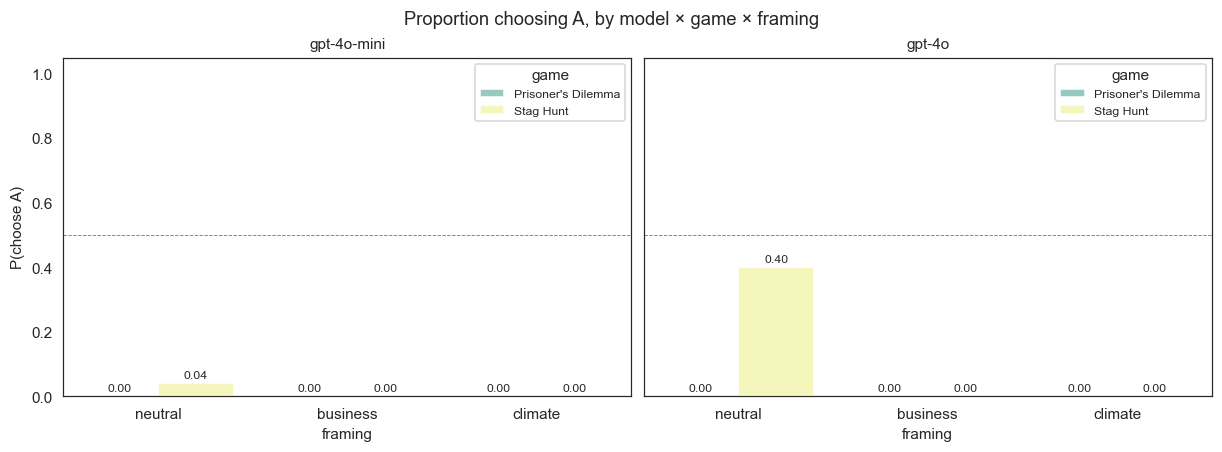

In [10]:
# Visualise: one panel per model, framings on x, game as hue.
plot_df = valid.groupby(['model', 'game', 'framing'])['A'].mean().reset_index()

fig, axes = plt.subplots(1, len(MODELS), figsize=(5.5 * len(MODELS), 4),
                         sharey=True, constrained_layout=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    sub = plot_df[plot_df['model'] == model]
    sns.barplot(data=sub, x='framing', y='A', hue='game',
                order=list(FRAMINGS.keys()),
                hue_order=list(GAMES.keys()), ax=ax)
    # Label every bar with its numeric value — important when many bars are at 0
    # and would otherwise be visually indistinguishable from "no data".
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', fontsize=8, padding=2)
    ax.set_title(model, fontsize=10)
    ax.set_ylabel('P(choose A)')
    ax.set_xlabel('framing')
    ax.set_ylim(0, 1.05)  # slight head-room for value labels
    ax.axhline(0.5, color='gray', ls='--', lw=0.6)
    ax.legend(title='game', fontsize=8)

plt.suptitle('Proportion choosing A, by model × game × framing', fontsize=12)
plt.show()

### How to read this plot

Two mental comparisons. For each model panel:

- **Vertical distance between the two bars within a single framing** = *structure effect*. Big gap → the model treats PD and Stag Hunt differently.
- **Horizontal variation in the same-coloured bar across framings** = *framing effect*. Lots of variation → the model's behaviour depends on the cover story.

The four archetypal patterns:

| structure gap | framing variation | signature |
|---|---|---|
| big | small | **reasoner** — payoffs matter, wrapper doesn't |
| small | big | **pattern-matcher** — wrapper matters, payoffs don't |
| big | big | **sensitive to both** — can't cleanly tell reasoning from contextual over-fitting |
| small | small | **unresponsive** — either a prior is dominating, or the factorial is too weak |

**What the actual GPT-4o / GPT-4o-mini data shows.** Most bars sit at 0.00. The business framing pulls P(A) to zero across *every* cell for both models. Climate sits at zero too. The only cells with any A-choices are on **Stag Hunt** under the **neutral** framing — GPT-4o at 0.40, GPT-4o-mini at 0.04. Every other cell is 0.00. Two readings of this:

1. **The business framing is a strong retrieval cue for self-interested play.** The same payoff matrix wrapped in "CEO of a technology firm" vocabulary reliably pushes both models into the risk-dominant equilibrium, even on Stag Hunt where the factorial has room for coordination. That looks like a *framing* effect in the narrow sense, but it's a framing effect whose target is the same as the rational-actor default — so it's hard to separate "framing pulls to B" from "rational play finds B".
2. **The only axis that does move is the PD / Stag Hunt distinction, and only under the neutral framing.** That single positive signal (0.00 → 0.40 on GPT-4o) is the factorial's one piece of evidence for a structure effect. Everything else is uniformity.

For Section 4 below: expect the structure-effect and framing-effect magnitudes to both be small, but the ratio to be *not* meaningless — because the signal that does exist is asymmetric across the axes. And expect the probe in Section 5 to collapse to a pile near 0, since it is pointed at the PD + business cell where the factorial already told us the model is glued to B.

---

## 4. The diagnostic — structure effect vs. framing effect

Instead of eyeballing the bars, we can compute the two effects directly. For each model:

- *Structure effect* = average, across framings, of the absolute gap between the two games' P(A).
- *Framing effect* = average, across games, of the range of P(A) across framings.

The ratio `structure_effect / framing_effect` is a rough reasoner-vs-pattern-matcher index. Larger than 1 → structure dominates; smaller → framing dominates.

In [11]:
def effects(sub: pd.DataFrame) -> pd.Series:
    """Main-effect magnitudes for one model's (game x framing) sub-table of P(A)."""
    tab = sub.pivot_table(values='A', index='game', columns='framing')
    # Structure = how much P(A) moves across games, averaged across framings
    structure = tab.max(axis=0).sub(tab.min(axis=0)).mean()
    # Framing = how much P(A) moves across framings, averaged across games
    framing = tab.max(axis=1).sub(tab.min(axis=1)).mean()
    return pd.Series({
        'structure_effect': structure,
        'framing_effect': framing,
        'ratio_structure_over_framing': structure / (framing + 1e-9),
    })


effects_table = valid.groupby('model').apply(effects)
effects_table.round(3)

,structure_effect,framing_effect,ratio_structure_over_framing
model,,,
gpt-4o,0.133,0.20,0.667
gpt-4o-mini,0.013,0.02,0.667


/Users/carinah/projects/konstanz-dynamic-social-behavior/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11014 (\N{UPWARDS BLACK ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/carinah/projects/konstanz-dynamic-social-behavior/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 11157 (\N{RIGHTWARDS BLACK ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


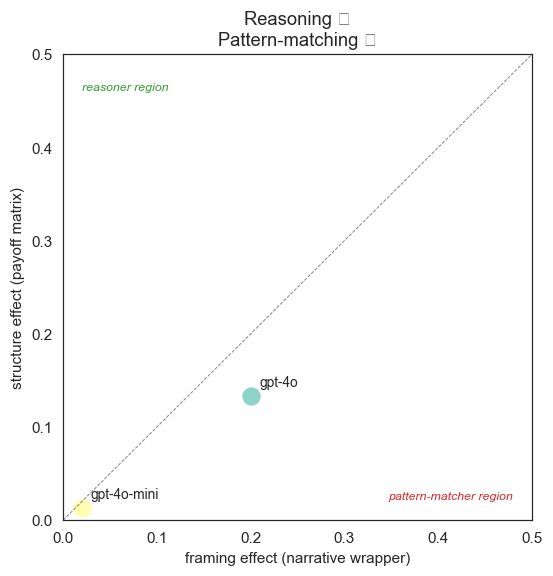

In [12]:
# Scatter the two effects against each other. Points far from the diagonal are the
# cleanly diagnosable models.
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for model, row in effects_table.iterrows():
    ax.scatter(row['framing_effect'], row['structure_effect'], s=120)
    ax.annotate(model, (row['framing_effect'], row['structure_effect']),
                xytext=(6, 6), textcoords='offset points', fontsize=9)

lim = max(effects_table[['framing_effect', 'structure_effect']].max().max() + 0.05, 0.5)
ax.plot([0, lim], [0, lim], color='gray', ls='--', lw=0.6)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('framing effect (narrative wrapper)')
ax.set_ylabel('structure effect (payoff matrix)')
ax.set_title('Reasoning ⬆\nPattern-matching ⮕')

# Annotate regions
ax.text(0.02, lim - 0.03, 'reasoner region', fontsize=8, color='tab:green',
        va='top', style='italic')
ax.text(lim - 0.02, 0.02, 'pattern-matcher region', fontsize=8, color='tab:red',
        ha='right', va='bottom', style='italic')
plt.show()

### Stop and interpret

- Which model lands higher on the structure axis? Which lands further right on the framing axis?
- Do the models sort in the order you'd guess from their capability tier (GPT-4o vs. GPT-4o-mini)?
- Is either model *above the diagonal* (cleanly a reasoner) or *below the diagonal* (cleanly a pattern-matcher)? Or are they clustered near the diagonal, where the diagnostic can't separate them?
- **What if both models sit near the origin**, with neither a structure effect nor a framing effect? That is what you see when a capable model has a dominant strategy it always picks (GPT-4o on the PD is a clean example). Uninformative for the diagnostic as designed, but itself a finding: an instance of the Kozlowski–Evans uniformity concern. Section 5 shows what the within-cell distribution looks like in that case, and Section 5b gives one concrete variation for pushing past it.

Remember the lecture's caution: a model that responds strongly to both axes is not necessarily failing — it may be doing exactly what a thoughtful human subject would do. But it *is* uninformative for the reasoning-vs-pattern-matching question, because the two interpretations are compatible with the same data.

---

## 5. The within-cell distribution — bimodality as a two-type signature

Everything so far has been aggregated: one number per cell. That's where most of the published literature stops. It's also where Lorè & Heydari did *not* stop, and the thing they noticed by looking further is what Part II of the chapter is about.

With binary A/B responses and only 25 runs per cell, bimodality is hard to see directly. So we change the response format for one cell: we ask the model for a *continuous* commitment on a 0–100 scale, and run it 100 times. If the resulting histogram bunches at the two extremes with an empty middle, we're looking at the signature Lorè & Heydari report for GPT-4 — a two-type distribution produced by the same model under the same prompt. If it bunches at *one* extreme, we have the Kozlowski–Evans uniformity signal instead.

**Pick one cell.** Default is GPT-4o on the Prisoner's Dilemma in the business framing — but you can change any of the three.

In [13]:
CONT_PROMPT_TEMPLATE = (
    'You are in a one-shot business negotiation with a competitor. You each '
    'simultaneously choose A (share innovation) or B (keep innovation private).\n\n'
    'Payoffs, in millions of dollars (yours, theirs):\n{payoffs}\n\n'
    'On a scale of 0 to 100, how strongly do you lean toward choosing A over B?\n'
    '0 = certainly B, 50 = perfectly undecided, 100 = certainly A.\n'
    'Respond with a single integer between 0 and 100. No other text.'
)


def parse_integer(text: str) -> int | None:
    m = re.search(r'\d{1,3}', text)
    if not m:
        return None
    n = int(m.group())
    return n if 0 <= n <= 100 else None


CONT_MODEL = 'gpt-4o'
CONT_GAME = "Prisoner's Dilemma"
CONT_N = 100

cont_prompt = CONT_PROMPT_TEMPLATE.format(payoffs=format_payoffs(CONT_GAME))
print(cont_prompt)

You are in a one-shot business negotiation with a competitor. You each simultaneously choose A (share innovation) or B (keep innovation private).

Payoffs, in millions of dollars (yours, theirs):
- If you choose A and they choose A: you get 3, they get 3
- If you choose A and they choose B: you get 0, they get 5
- If you choose B and they choose A: you get 5, they get 0
- If you choose B and they choose B: you get 1, they get 1

On a scale of 0 to 100, how strongly do you lean toward choosing A over B?
0 = certainly B, 50 = perfectly undecided, 100 = certainly A.
Respond with a single integer between 0 and 100. No other text.


In [14]:
if BIMODALITY_CACHE.exists():
    bimodal_df = pd.read_csv(BIMODALITY_CACHE)
    raws = bimodal_df['raw'].tolist()
    confidences = [int(n) for n in bimodal_df['confidence'].dropna().tolist()]
    print(f'Loaded {len(raws)} cached responses from {BIMODALITY_CACHE}.')
elif client is not None:
    confidences = []
    raws = []
    for _ in tqdm(range(CONT_N), desc='bimodality probe'):
        raw = ask(CONT_MODEL, cont_prompt, max_tokens=6)
        n = parse_integer(raw)
        raws.append(raw)
        if n is not None:
            confidences.append(n)
        time.sleep(0.05)

    bimodal_df = pd.DataFrame({
        'raw': raws,
        'confidence': [parse_integer(r) for r in raws],
    })
    bimodal_df.to_csv(BIMODALITY_CACHE, index=False)
    print(f'\nCollected {len(confidences)} / {CONT_N} valid responses; cache written to {BIMODALITY_CACHE}.')
else:
    raise RuntimeError(
        f'No cache at {BIMODALITY_CACHE} and no OPENAI_API_KEY set.'
    )

if len(confidences) < 0.7 * CONT_N:
    print('(Low parse rate — the model is probably refusing the numeric format.)')
    print('Sample raw responses:', raws[:5])

Loaded 100 cached responses from 2_structure_vs_framing_bimodality_cache.csv.


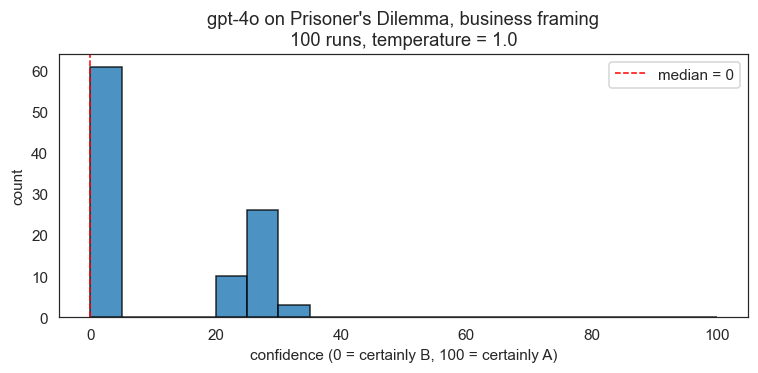

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(confidences, bins=20, range=(0, 100), edgecolor='black', color='tab:blue', alpha=0.8)
ax.set_xlabel('confidence (0 = certainly B, 100 = certainly A)')
ax.set_ylabel('count')
ax.set_title(f'{CONT_MODEL} on {CONT_GAME}, business framing\n'
             f'{len(confidences)} runs, temperature = 1.0')
ax.axvline(np.median(confidences), color='red', ls='--', lw=1,
           label=f'median = {np.median(confidences):.0f}')
ax.legend()
plt.tight_layout()
plt.show()

### What to look for

Three characteristic shapes, ordered by how likely you are to see them with current GPT-class models:

1. **Unimodal pile near 0 or 100.** The model has locked onto a single action. GPT-4o and GPT-4o-mini produce this on the Prisoner's Dilemma (business framing): near-pure defect, a pile near 0 on every one of 100 runs. **This is the most common shape you will see.** It is not a bug — it is the **Kozlowski–Evans uniformity signal** in miniature: the same model across 100 initializations produces a narrower distribution than a human population would (see §9 of the lecture).
2. **Unimodal pile near 50.** The model is uncertain. Unusual — if the game has a dominant strategy, this would be informative, because it would mean the model has not extracted the structure.
3. **Bimodal, piles at both ends with empty middle.** The two-type signature Lorè & Heydari report for GPT-4 on earlier snapshots, and what classical behavioural GT read as a *mixture of types*: conditional cooperators and free-riders, each internally consistent. Rare with current models.

If you got shape 1 — most likely — the diagnostic in Sections 3/4 is uninformative: there is no variance to split across axes. **Section 5b** below gives a concrete variation (persona prepending) for eliciting variance; further options live in Section 6.

If you saw shape 3, the collapsed-to-a-proportion analysis in Section 3 was throwing away exactly the most interesting pattern in the data. That's the wedge Part II of the lecture drives into the literature.

---

## 5b. Variation: persona sweep

The factorial in Section 3 came back with **uniformity**: GPT-4o and GPT-4o-mini defect (B) in nearly every cell, regardless of game or framing. The bimodality probe in Section 5 collapsed to a single pile near 0. That is not a broken notebook — it is a result. It is the same pattern Kozlowski & Evans (§9 of the lecture) flag as a validity concern: *much narrower within-prompt variance than a human population would show*.

If we want the structure-vs-framing diagnostic to actually diagnose, we need to elicit variance somehow. The cleanest first test — and a direct replication of Horton's thesis that persona prompting acts as a steerable knob — is a **persona sweep**: hold the game and the framing fixed, vary the identity the LLM is asked to adopt (baseline / cooperative / ruthless), and see how much P(A) moves.

The cells below run exactly that on one fixed (model, game, framing) probe cell. Further variations worth trying are collected in Section 6 as group-project seeds.

In [16]:
# === Variation: persona sweep on a single cell ===
# Pick one (model, game, framing) cell and probe it with three personas.
# How much variance does persona buy back that game+framing did not produce?

PERSONAS = {
    'baseline':    '',
    'cooperative': 'You are a cooperative team player who values joint outcomes and building long-term trust. ',
    'ruthless':    'You are a ruthless, self-interested game theorist focused purely on maximising your own payoff. ',
}

PROBE_MODEL   = 'gpt-4o'
PROBE_GAME    = "Prisoner's Dilemma"
PROBE_FRAMING = 'business'
PROBE_N       = 25

PERSONA_CACHE = CACHE_DIR / '2_structure_vs_framing_persona_cache.csv'

if PERSONA_CACHE.exists():
    persona_df = pd.read_csv(PERSONA_CACHE)
    print(f'Loaded {len(persona_df)} cached persona responses from {PERSONA_CACHE}.')
elif client is not None:
    records = []
    base_prompt = build_prompt(PROBE_GAME, PROBE_FRAMING)
    with tqdm(total=len(PERSONAS) * PROBE_N, desc='persona sweep') as pbar:
        for persona, prefix in PERSONAS.items():
            prompt = prefix + base_prompt
            for run in range(PROBE_N):
                raw = ask(PROBE_MODEL, prompt)
                records.append({
                    'persona': persona,
                    'model':   PROBE_MODEL,
                    'game':    PROBE_GAME,
                    'framing': PROBE_FRAMING,
                    'run':     run,
                    'raw':     raw,
                    'choice':  parse_choice(raw),
                })
                pbar.update(1)
                time.sleep(0.05)
    persona_df = pd.DataFrame(records)
    persona_df.to_csv(PERSONA_CACHE, index=False)
    print(f'\nCollected {len(persona_df)} responses; cache written to {PERSONA_CACHE}.')
else:
    raise RuntimeError(
        f'No cache at {PERSONA_CACHE} and no OPENAI_API_KEY set. '
        'Obtain the cache file from the repo, or set an API key and restart.'
    )

# P(A) by persona
p_a_by_persona = (persona_df.dropna(subset=['choice'])
                  .assign(A=lambda d: (d['choice'] == 'A').astype(int))
                  .groupby('persona')['A'].mean()
                  .reindex(list(PERSONAS.keys())))
print(f'\nP(choose A) on {PROBE_MODEL} · {PROBE_GAME} · {PROBE_FRAMING} framing:')
print(p_a_by_persona.round(2))

Loaded 75 cached persona responses from 2_structure_vs_framing_persona_cache.csv.

P(choose A) on gpt-4o · Prisoner's Dilemma · business framing:
persona
baseline       0.0
cooperative    0.0
ruthless       0.0
Name: A, dtype: float64


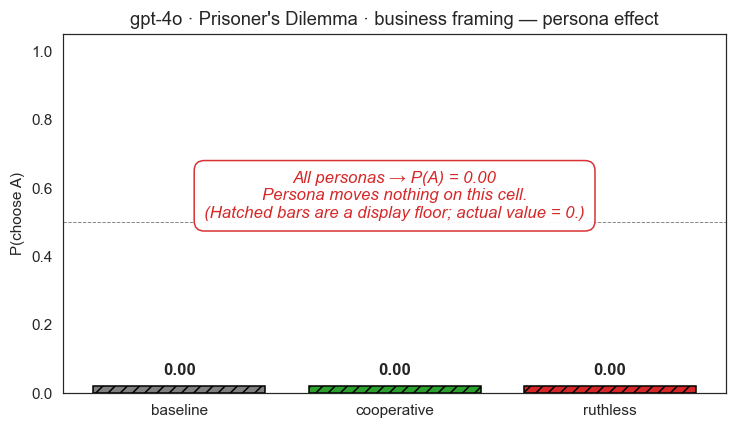

In [17]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
colors = ['tab:gray', 'tab:green', 'tab:red']
vals = p_a_by_persona.values
names = list(p_a_by_persona.index)

# Give zero-height bars a minimum visible stripe so students can still see the bars exist.
# Hatching on those bars signals "displayed floor, actual value = 0".
MIN_VISIBLE = 0.02
display_h = np.maximum(vals, MIN_VISIBLE)
bars = ax.bar(names, display_h, color=colors[:len(names)], edgecolor='black', linewidth=1)
for bar, v in zip(bars, vals):
    if v < 0.01:
        bar.set_hatch('///')

ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='gray', ls='--', lw=0.6)
ax.set_ylabel('P(choose A)')
ax.set_title(f'{PROBE_MODEL} · {PROBE_GAME} · {PROBE_FRAMING} framing — persona effect')

# Bold value labels above each bar
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, max(v, MIN_VISIBLE) + 0.025,
            f'{v:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Prominent callout when all bars collapse to zero
if all(v < 0.01 for v in vals):
    ax.text(0.5, 0.55,
            'All personas → P(A) = 0.00\nPersona moves nothing on this cell.\n(Hatched bars are a display floor; actual value = 0.)',
            transform=ax.transAxes, ha='center', va='center',
            fontsize=11, style='italic', color='tab:red',
            bbox=dict(boxstyle='round,pad=0.6', facecolor='white',
                      edgecolor='tab:red', alpha=0.95))

plt.tight_layout()
plt.show()

### How to read the persona sweep

Three comparisons in principle:

- **Baseline vs. cooperative** — the persona's *prosocial pull* (how much a cooperative identity moves the model toward A).
- **Baseline vs. ruthless** — the *selfish pull* (usually small on the PD, since *baseline* is already near-pure defect for a capable model).
- **Cooperative vs. ruthless** — the full persona effect, the size of the knob.

**What the actual data shows.** On GPT-4o in the PD + business cell, all three personas produce P(A) = 0.00. Baseline defects. "Ruthless" defects. Even *"cooperative"* defects on all 25 runs. Persona moves **nothing**.

That is not a small finding — it is the **strongest possible Kozlowski–Evans uniformity signal** this notebook can produce: a model whose policy is so locked to the dominant strategy on this prompt that neither narrative wrapper (Section 3) nor stated identity (here) can dislodge it. Horton's thesis — that persona prompting acts as a steerable knob for LLM behaviour — is *not* supported on this cell for this model. If you want to put a number on the degree of uniformity, this is a cleaner measurement than Section 5's continuous probe: three explicit identity interventions, zero movement.

**Where persona might actually matter.** The cell we probed is close to the worst case for seeing a persona effect, because PD + business is where GPT-4o's default pull to B is most absolute. The factorial in Section 3 had exactly one cell with meaningful variation: **GPT-4o on Stag Hunt under the *neutral* framing**, where P(A) ≈ 0.40. That is where personas have the most room to shift the distribution in either direction.

**To rerun on Stag Hunt + neutral:** edit the cell above to set `PROBE_GAME = 'Stag Hunt'`, `PROBE_FRAMING = 'neutral'`, *and* delete `2_structure_vs_framing_persona_cache.csv` (or rename `PERSONA_CACHE` in the code) — otherwise the cached PD/business results will load instead. Budget: ~75 additional API calls, under a minute.

---

## 6. Group-project sparks

A few directions the original Lorè & Heydari factorial doesn't answer. Treat them as inspiration, not recipes — each is harder than the one-line hook suggests.

- **Cross-family replication.** Is the structure-vs-framing pattern a property of GPT-4o, or of LLMs as a class?
- **More framings.** How many framings are needed before the framing effect saturates? Does the rank order of framings agree across models?
- **Temperature sweep.** At T = 0, does any bimodality survive? A bimodal pattern that vanishes at T=0 is noise, not mixture.
- **Extended persona sweep.** Does persona interact with game structure? Where exactly does Horton's thesis actually hold?
- **Reasoning-vs-action gap.** When every action is B, do the *reasons given* for B vary across framings? Do Fan's *belief overlooked* / *belief modified* failure modes replicate?
- **Stag Hunt with theory-of-mind scaffold.** Does "*assume the other player will reason exactly as you do*" flip the distribution? This is Akata's SCoT, moved into a one-shot game.
- **Akata trajectory data.** Can the Week 2 DTW toolkit recover within-model behavioural clusters from Akata's 1,224 × 10-round trajectories? The missed-mixture diagnosis, closed with existing data.

Each of these is a hook, not a plan. The work is in turning the question into a specific hypothesis your notebook can answer.